# Preamble

In [1]:
import pandas as pd
import numpy as np

import math

from scipy.stats import normaltest

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
customer = pd.read_csv('customer.csv')
order = pd.read_csv('order.csv')
order_detail = pd.read_csv('order_detail.csv')
product = pd.read_csv('product.csv')
returned = pd.read_csv('returned.csv')
shipping = pd.read_csv('shipping.csv')

# Preprocessing

In [3]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer ID    1589 non-null   str  
 1   Customer Name  1589 non-null   str  
 2   Segment        1589 non-null   str  
dtypes: str(3)
memory usage: 82.9 KB


In [4]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order ID        25033 non-null  str  
 1   Customer ID     25033 non-null  str  
 2   Order Priority  25033 non-null  str  
 3   Order Date      25033 non-null  str  
 4   Market          25033 non-null  str  
dtypes: str(5)
memory usage: 2.1 MB


In [5]:
order_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         49670 non-null  int64  
 1   Order ID       49670 non-null  str    
 2   Product ID     49670 non-null  str    
 3   Sales          49670 non-null  float64
 4   Quantity       49670 non-null  int64  
 5   Discount       49670 non-null  float64
 6   Profit         49670 non-null  float64
 7   Shipping Cost  49670 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 4.4 MB


In [6]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 10246 entries, 0 to 10245
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Product ID    10246 non-null  str  
 1   Product Name  10246 non-null  str  
 2   Category      10246 non-null  str  
 3   Sub-Category  10246 non-null  str  
dtypes: str(4)
memory usage: 983.2 KB


In [7]:
returned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order ID  1172 non-null   str  
dtypes: str(1)
memory usage: 25.3 KB


In [8]:
shipping.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Shipping ID  25033 non-null  int64
 1   Order ID     25033 non-null  str  
 2   Ship Date    25033 non-null  str  
 3   Ship Mode    25033 non-null  str  
 4   City         25033 non-null  str  
 5   State        25033 non-null  str  
 6   Country      25033 non-null  str  
 7   Region       25033 non-null  str  
dtypes: int64(1), str(7)
memory usage: 3.4 MB


In [9]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AA-315,Alex Avila,Consumer


In [10]:
order.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-8865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-4110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-7380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-8820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-4665,Medium,2014-12-13 00:00:00,EMEA


In [11]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [12]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [13]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [14]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [15]:
customer.describe()

,Customer ID,Customer Name,Segment
count,1589,1589,1589
unique,1589,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,2,817


In [16]:
order.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,1589,4,1428,7
top,AE-2011-9160,PO-18850,Medium,2014-11-25 00:00:00,APAC
freq,1,41,14344,59,5437


In [17]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [18]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [19]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [20]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
returned["Returned"] = 1

In [22]:
df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned , on="Order ID" , how="left")

In [23]:
df

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-20575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,NaN
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49665,51286,HU-2012-7730,OFF-AVE-10004570,11.07,1,0.0,3.42,1.980,NF-8385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49666,51287,HU-2012-7730,TEC-LOG-10004419,61.44,2,0.0,18.42,13.020,NF-8385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49667,51288,HU-2012-7730,OFF-BOS-10002705,80.52,4,0.0,20.88,8.780,NF-8385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49668,51289,HU-2012-7730,OFF-ENE-10004132,130.44,4,0.0,33.84,18.970,NF-8385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN


In [24]:
df['Row ID'].unique()

array([    1,     2,     3, ..., 51288, 51289, 51290], shape=(49670,))

In [25]:
df.drop(columns="Row ID" , inplace=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  str    
 1   Product ID      49670 non-null  str    
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  str    
 8   Order Priority  49670 non-null  str    
 9   Order Date      49670 non-null  str    
 10  Market          49670 non-null  str    
 11  Product Name    49670 non-null  str    
 12  Category        49670 non-null  str    
 13  Sub-Category    49670 non-null  str    
 14  Customer Name   49670 non-null  str    
 15  Segment         49670 non-null  str    
 16  Shipping ID     49670 non-null  int64  
 17  Ship Date       49670 non-null  str    
 1

In [27]:
df["Returned"] = df["Returned"].fillna(0)

In [28]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125,31632.081639,0.059996
std,485.963091,2.274854,0.212046,172.399520,56.870281,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.980000,0.002000,21043.000000,0.000000
25%,30.384000,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970000,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.830000,5.000000,0.200000,36.266400,23.969000,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980000,933.570000,46075.000000,1.000000


In [29]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

In [30]:
category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

In [31]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        49670 non-null  str           
 1   Product ID      49670 non-null  str           
 2   Sales           49670 non-null  float32       
 3   Quantity        49670 non-null  int8          
 4   Discount        49670 non-null  float32       
 5   Profit          49670 non-null  float32       
 6   Shipping Cost   49670 non-null  float32       
 7   Customer ID     49670 non-null  str           
 8   Order Priority  49670 non-null  category      
 9   Order Date      49670 non-null  datetime64[us]
 10  Market          49670 non-null  category      
 11  Product Name    49670 non-null  str           
 12  Category        49670 non-null  category      
 13  Sub-Category    49670 non-null  category      
 14  Customer Name   49670 non-null  str           
 15  Segment      

In [33]:
numeric_columns = ['Sales' , 'Quantity' , 'Discount' , 'Profit' , 'Shipping Cost']

In [34]:
categorical_columns = ["Order Priority" ,
"Market" , 
"Category" , 
"Sub-Category" ,
"Segment" , 
"Ship Mode" ,
"City" , 
"State" , 
"Country" , 
"Region" ,
"Returned", ]

## Duplicates

In [35]:
df.duplicated().sum()

np.int64(0)

## Nan

In [36]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [37]:
nan_percentage(df)

,Missing Count,Nan Percent
Order ID,0,0.0
Product ID,0,0.0
Sales,0,0.0
Quantity,0,0.0
Discount,0,0.0
Profit,0,0.0
Shipping Cost,0,0.0
Customer ID,0,0.0
Order Priority,0,0.0
Order Date,0,0.0


## Outliers

# EDA

## Normality

In [38]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        
        stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [39]:
normality_checker(df)

,Column,Sample Size,p-value,Result
0,Sales,49670,0.0,Not normal
1,Quantity,49670,0.0,Not normal
2,Discount,49670,0.0,Not normal
3,Profit,49670,0.0,Not normal
4,Shipping Cost,49670,0.0,Not normal
5,Shipping ID,49670,0.0,Not normal
6,Returned,49670,0.0,Not normal


## Visualization

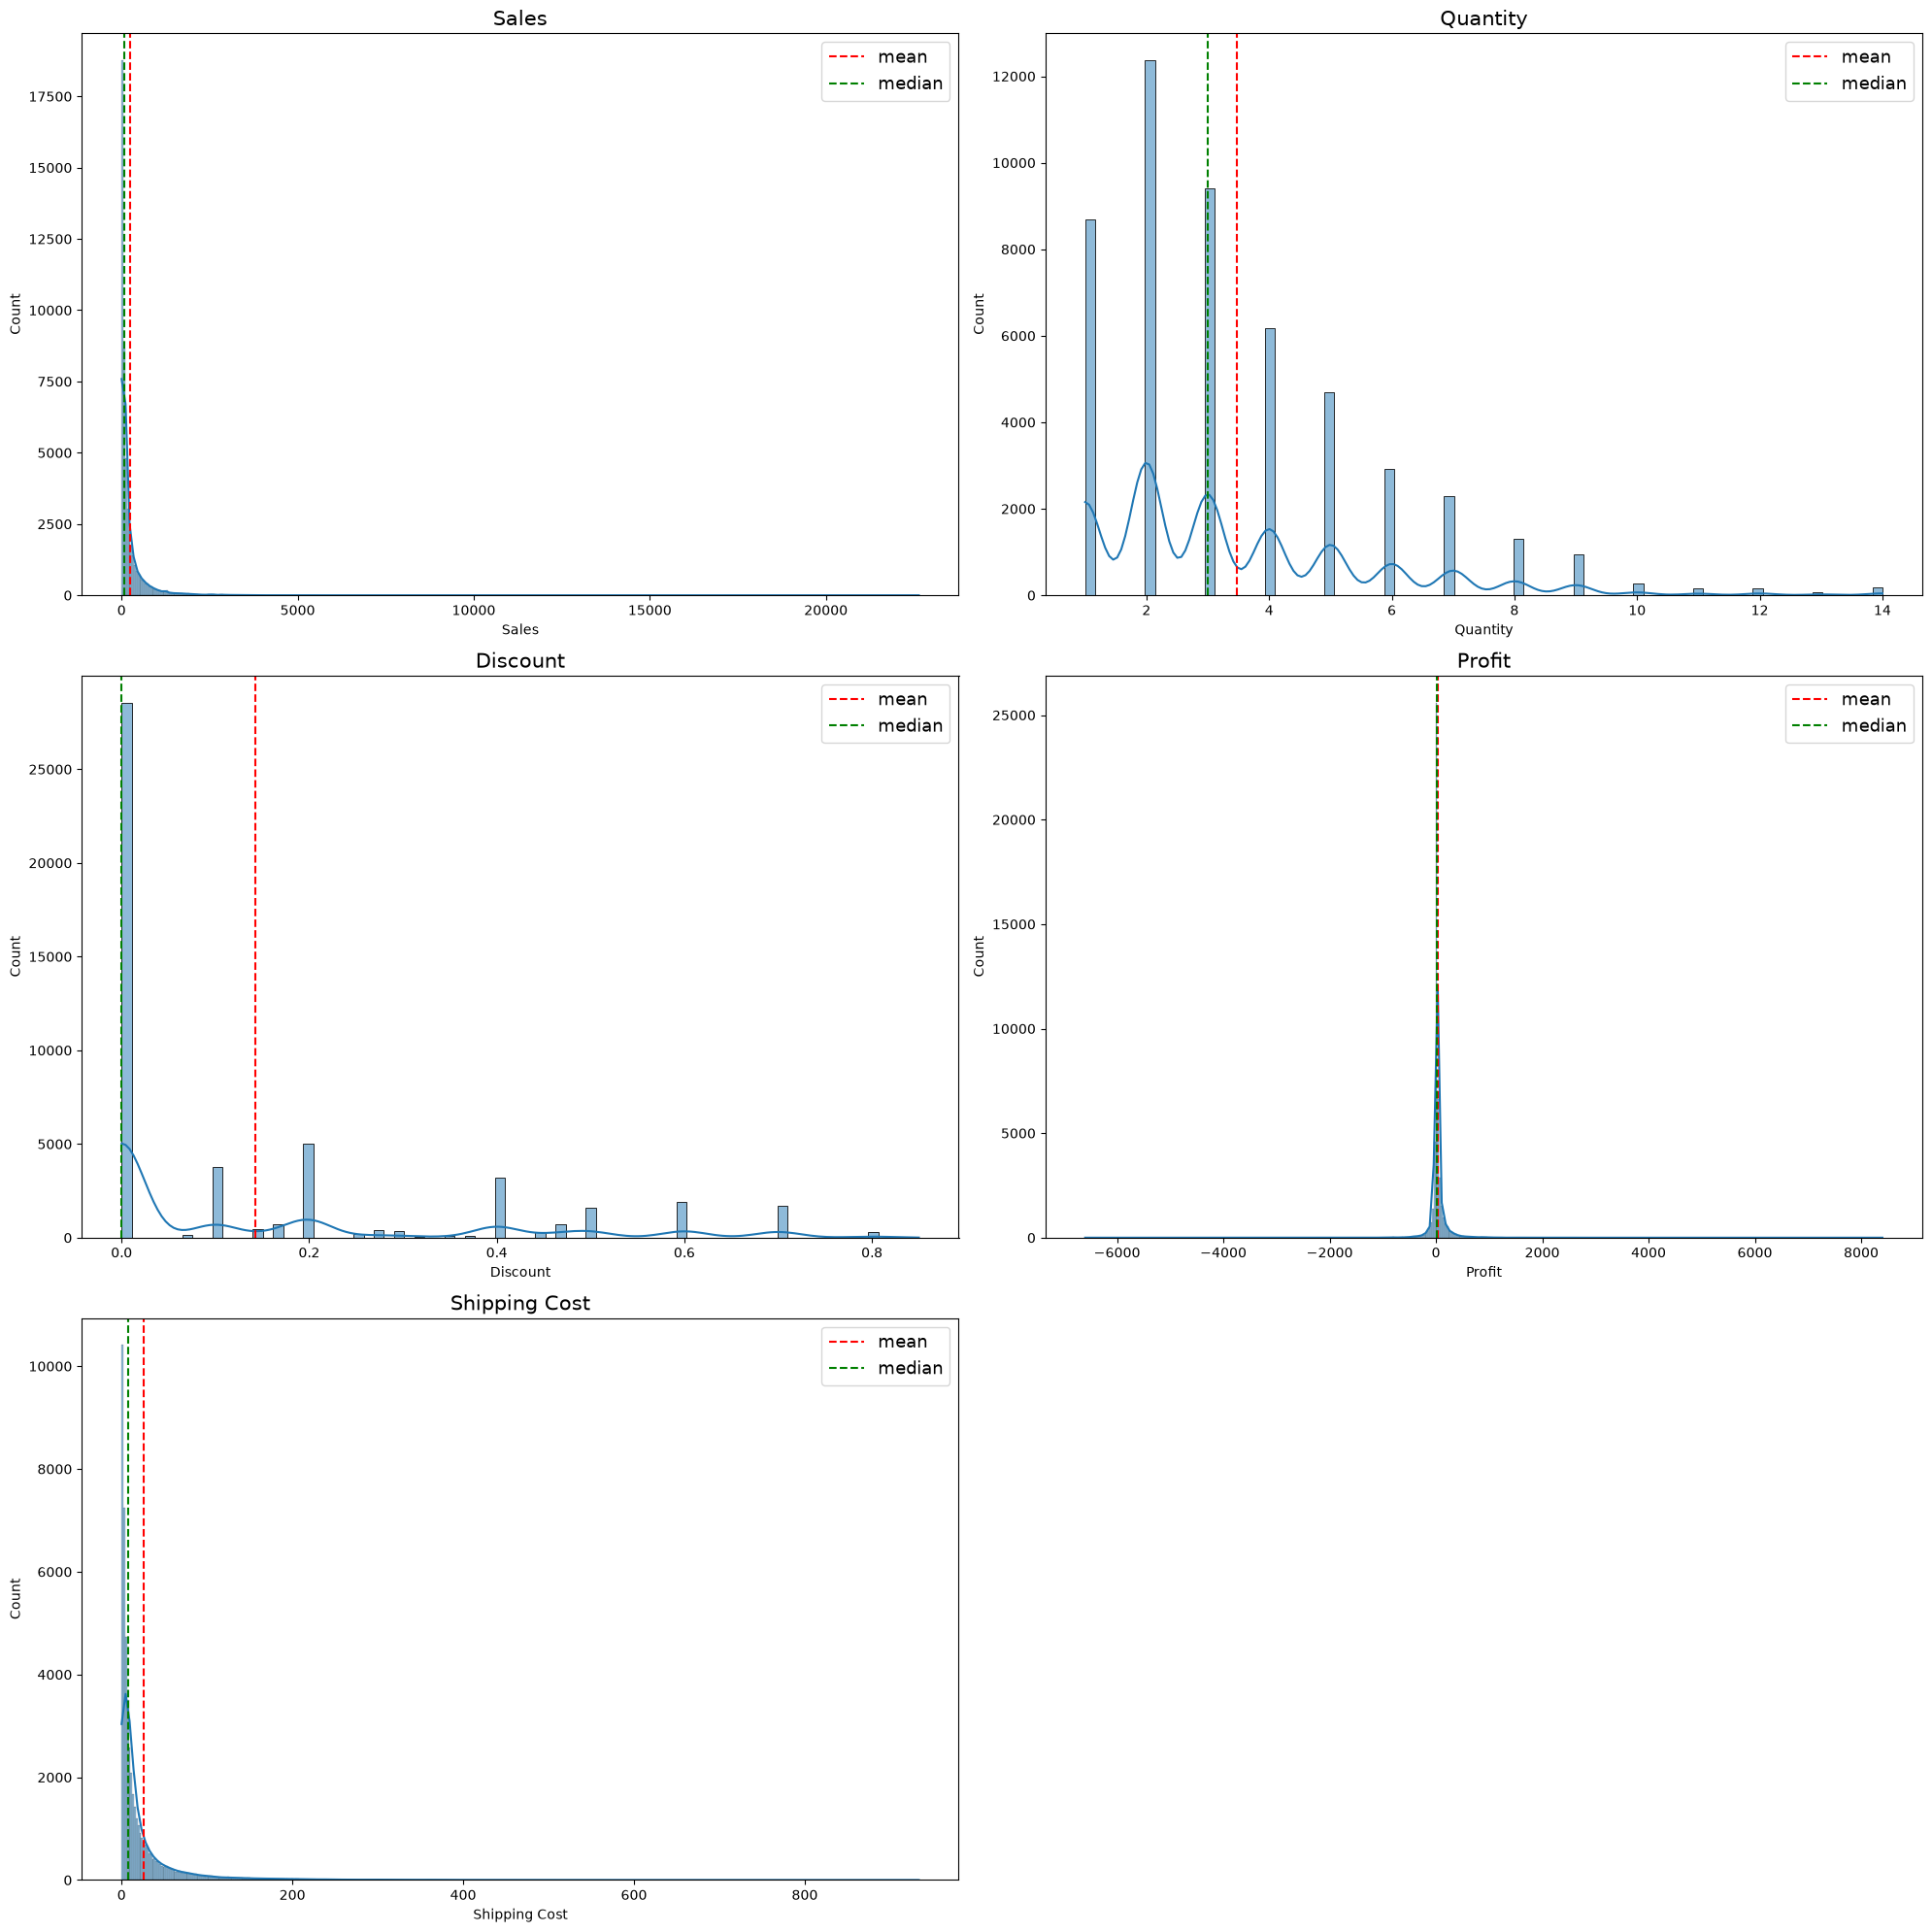

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(df[c], kde=True, ax=ax)
    ax.axvline(df[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(df[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=15)
    ax.legend(fontsize=13)

for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


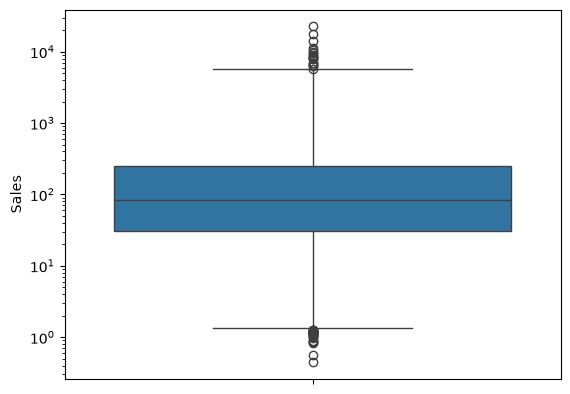

In [41]:
sns.boxplot(df['Sales'] , log_scale=True)
plt.show()

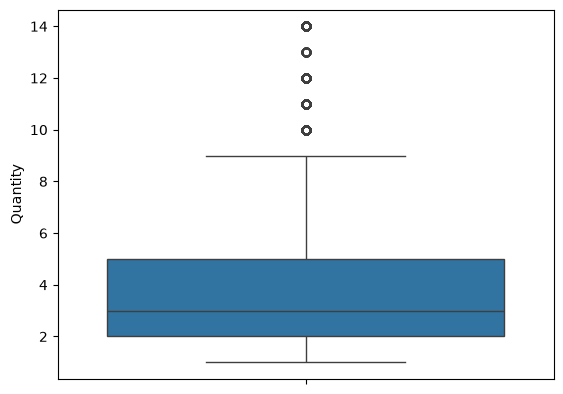

In [42]:
sns.boxplot(df['Quantity'])
plt.show()

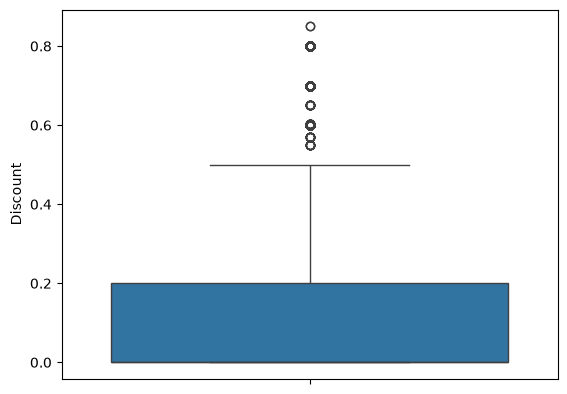

In [43]:
sns.boxplot(df['Discount'])
plt.show()

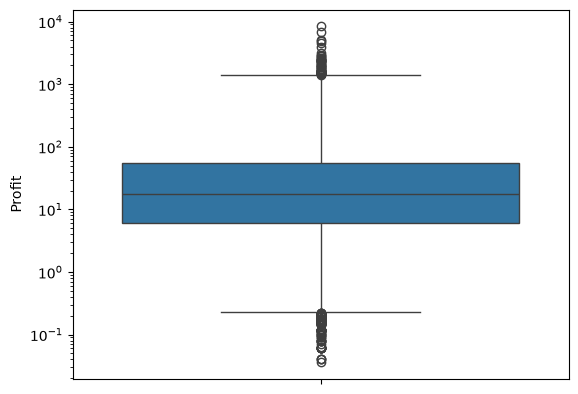

In [44]:
sns.boxplot(df['Profit'] , log_scale=True)
plt.show()

In [45]:
categorical_columns

['Order Priority',
 'Market',
 'Category',
 'Sub-Category',
 'Segment',
 'Ship Mode',
 'City',
 'State',
 'Country',
 'Region',
 'Returned']

In [46]:
fig = px.pie(
    df,
    names="Order Priority",
    title="Distribution of Order Priority"
)

fig.update_traces(textinfo="percent+label")
fig.show()